# Convergence of the generalized Newton–Schulz iteration
One matrix, several degrees D. Each iterate is frozen once its error reaches `eps` and the error is held until `k_max`; for a rank-deficient matrix keep `eps` above the noise floor (about $u/\sigma_{\min}$). Edit the config and rerun.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.convergence import ConvergenceConfig, run_convergence
%matplotlib inline

In [9]:
cfg = ConvergenceConfig(
    m=64, n=64, rank=None, cond=2, sigma_max=1.0, spectrum="log", degrees=[1, 10, 20],
    k_max=50,     # steps run at most
    eps=None,    # freeze the iterate once its error reaches this; None = 10 machine eps
                  # (rank-deficient: keep eps above the noise floor, about u * cond)
    dtype=torch.float64, device="cuda", seed=0,
)
res = run_convergence(cfg)

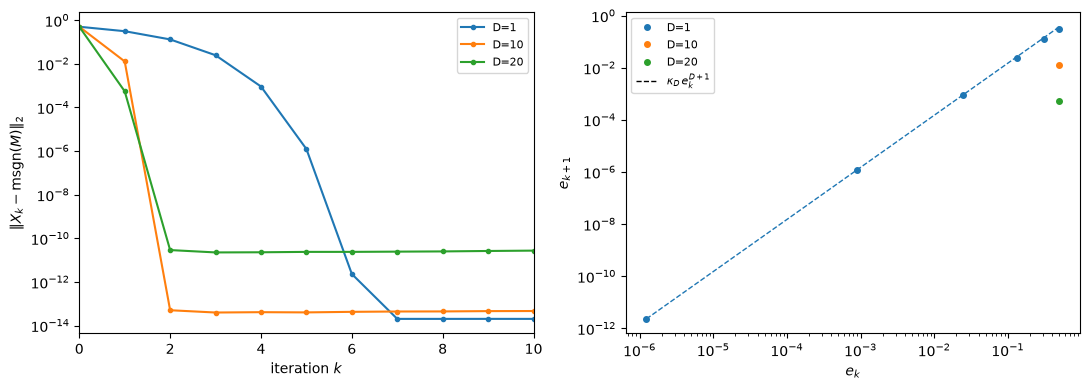

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
plots.plot_error_curves(
    res["error"], ax=axs[0],
    eps=None,              # set a level (e.g. 1e-8) to enable the first-hit markers and the eps line
    predicted=None,        # e.g. {D: K_D} to draw predicted step counts
    show_predicted=True,   # dashed vertical lines at predicted K_D
    show_first_hit=True,   # mark the first step with error <= eps
    show_eps_line=True,    # horizontal line at eps
    k_plot=10,           # last step shown (None = all)
)
plots.plot_error_map(res["error"], ax=axs[1])
fig.tight_layout()